# Bluesky Data Science
## Part 01 - Collecting Data at Scale: Pagination, Rate Limits, and Research Ethics

June 2026
Copyright and distributed under an [MIT License](https://opensource.org/licenses/MIT)

## Background

> **tl;dr**: Part 00 retrieved a handful of records at a time. Real research questions require thousands of posts or follows, which means traversing cursors, respecting rate limits, and thinking carefully about the ethics of collecting other people's (public) data *before* you start.

In [Part 00](../Part%2000%20-%20Introduction.ipynb) we set up the ATProto Python SDK, retrieved profiles, and pulled a single page of posts and follows. That is enough to kick the tires, but it is not enough to do research. If you want to characterize an account's posting behavior over three years, map the structure of its social network, or build a corpus for content analysis, you need *complete* collections: every post, every follow, every follower.

The Bluesky API — like virtually every social media API before it — will not hand you a complete collection in one response. Instead, endpoints deliver results in *pages* of at most 100 records, each accompanied by a **cursor**: a bookmark that tells the server where to resume. Splitting a large result set across many requests this way is called **pagination**, and collecting at scale means writing loops that follow cursors until the data runs out. It also means staying inside the platform's **rate limits** — caps on how many requests one client may make in a given time window — and being a polite guest on infrastructure someone else pays for.

Three reference sites will recur throughout: the [official Bluesky API documentation](https://docs.bsky.app) describes every endpoint we call; the [AT Protocol specifications](https://atproto.com) explain the underlying plumbing (identifiers, lexicons, federation); and [atproto.blue](https://atproto.blue) documents the Python SDK that wraps it all. When a method behaves unexpectedly, those are the places to look before guessing.

This is also the right moment to slow down and think like a researcher rather than a programmer. Fifteen years of Twitter scholarship taught computational social science some hard lessons about haphazard data collection: samples assembled without a defined population produce findings that do not generalize (Ruths & Pfeffer 2014), platforms can revoke the data access an entire field depends on (Freelon 2018), and the users whose posts we collect mostly have no idea researchers are watching (Fiesler & Proferes 2018). We will return to all three papers throughout this notebook.

### Learning objectives

By the end of this notebook you will be able to:

1. Define a **sampling frame** — what you will collect, from whom, and why — before writing any collection code.
2. Explain how **cursor-based pagination** works and paginate any ATProto list endpoint manually.
3. Write and reuse a **generic collection loop** (`fetch_all_pages` in `collection.py`) with stopping conditions and polite sleeping.
4. Read Bluesky's **rate-limit headers** and implement **exponential backoff** for HTTP 429 errors.
5. **Flatten** the SDK's nested Pydantic models into tidy Pandas DataFrames.
6. **Persist** archives to CSV and Parquet with metadata that makes collections reproducible.
7. Reason about the **ethics** of collecting public social media data: consent, minimization, third parties, deletion, terms of service, and institutional review.

## Setup

We need a few common libraries: [`requests`](https://requests.readthedocs.io/) for talking to web servers directly (we will use it to inspect rate-limit headers that the SDK hides from us), `json` and `time` from the standard library, and the usual [pandas](https://pandas.pydata.org/docs/) / [NumPy](https://numpy.org/doc/stable/) / [Matplotlib](https://matplotlib.org/stable/) stack for data wrangling and plotting. If any import fails, install the dependencies with `python3 -m pip install -r requirements.txt` from the repository root, as described in Part 00.

In [1]:
# Talking to web servers directly (to inspect rate-limit headers)
import requests

# APIs speak JSON
import json

# Pausing politely between requests
import time

# Handling dates and times
from datetime import datetime, timezone

# File paths and file sizes
from pathlib import Path

# DataFrames
import pandas as pd
import numpy as np

# Data visualization
%matplotlib inline
import matplotlib.pyplot as plt

Rather than pasting the login boilerplate from Part 00 into every notebook, this series ships a small helper module, `bsky_client.py`, in each notebook's directory. Its `get_client()` function returns an **authenticated** client if you saved your credentials in an `atproto.json` file (see Part 00), and otherwise falls back to an **unauthenticated** client pointed at Bluesky's public AppView (`https://public.api.bsky.app`), which serves most read endpoints without logging in. Everything in this notebook works either way. (If authentication is unfamiliar, [Part 00](../Part%2000%20-%20Introduction.ipynb) walks through it step by step.)

In [2]:
from bsky_client import get_client, is_authenticated

client = get_client()

No atproto.json found: using the unauthenticated public AppView.
Read endpoints work; search and write endpoints require logging in.


## 1. Before you collect: define a sampling frame

It is tempting to start writing loops immediately. Resist. The single highest-leverage research decision happens before any code runs: defining your **sampling frame** — the complete list of units (accounts, posts, hashtags, time windows) your collection is supposed to cover, and the population those units are meant to represent.

Why does this matter so much? Ruths & Pfeffer (2014) catalogued how social media studies go wrong when the sample is whatever the API made convenient: platform populations are not human populations, search indexes silently drop content, and collection methods (search vs. streaming vs. crawling) each have their own biases. A finding like "40% of posts about X are negative" is uninterpretable unless you can say *40% of which posts, collected how, from what population, during what window*. The defense against this is not fancier statistics — it is writing down, in advance, exactly what your collection will and will not contain.

For this notebook our sampling frame is deliberately simple and defensible:

* **Unit**: one account, [`brianckeegan.com`](https://bsky.app/profile/brianckeegan.com) — the author of this series, who has consented to being the example (a courtesy we'll discuss in the ethics section).
* **Records**: the account's *complete* posting history, plus its *complete* follows and followers lists.
* **Window**: everything from account creation to the collection timestamp we will record alongside the data.

A complete single-account census like this avoids sampling bias by definition — there is no sampling. Multi-account designs (Parts 02–05) have to work much harder to justify their frames.

Let's size up the job. The profile object tells us how many records each collection should contain, which lets us estimate how many requests we'll make — a number you should *always* compute before unleashing a loop on someone else's servers.

In [3]:
HANDLE = 'brianckeegan.com'

profile = client.get_profile(HANDLE)

print(f"Account:   {profile.handle} ({profile.did})")
print(f"Created:   {profile.created_at}")
print(f"Posts:     {profile.posts_count:,}")
print(f"Follows:   {profile.follows_count:,}")
print(f"Followers: {profile.followers_count:,}")

Account:   brianckeegan.com (did:plc:lse7quaysss2d3xxm76mouhd)
Created:   2023-05-25T20:28:43.424Z
Posts:     3,369
Follows:   2,448
Followers: 4,982


Now translate those counts into a **request budget**. Each paginated endpoint returns at most 100 records per request, so dividing each count by the page size — rounding up with NumPy's [`np.ceil`](https://numpy.org/doc/stable/reference/generated/numpy.ceil.html), since a final partial page still costs one request — tells us how many requests each collection will take:

In [4]:
PAGE_SIZE = 100  # the maximum `limit` these endpoints accept per request

for name, count in [('posts', profile.posts_count),
                    ('follows', profile.follows_count),
                    ('followers', profile.followers_count)]:
    pages = int(np.ceil(count / PAGE_SIZE))
    print(f"{name:>9}: {count:>6,} records ≈ {pages:>3} requests")

    posts:  3,369 records ≈  34 requests
  follows:  2,448 records ≈  25 requests
followers:  4,982 records ≈  50 requests


A bit over a hundred requests in total — trivially small next to the rate limits we'll meet in Section 3, but the habit of estimating first is what keeps you from accidentally writing a loop that issues 500,000 requests against an account with 50 million followers.

One more planning note: the `posts_count` field counts the account's *own* posts. The author-feed endpoint we are about to paginate also returns the account's **reposts** of other people's posts, so we should expect somewhat more feed items than `posts_count` — and we will need to tell the two apart when we build our DataFrame in Section 4.

## 2. The anatomy of a paginated endpoint

Let's look closely at one paginated response before we automate anything. As in Part 00, `get_author_feed` (the SDK's wrapper around the [`app.bsky.feed.getAuthorFeed`](https://docs.bsky.app/docs/api/app-bsky-feed-get-author-feed) lexicon) returns an account's posts, newest first, up to `limit=100` at a time. We ask for the largest page the endpoint allows and count what comes back:

In [5]:
page1 = client.get_author_feed(
    actor = HANDLE,
    limit = 100
)

len(page1.feed)

100

One hundred posts out of a few thousand. So how do we get the next hundred? Alongside the `.feed` list, the response carries a `.cursor` attribute:

In [6]:
page1.cursor

'2026-05-23T03:00:58.549Z'

A cursor is an **opaque bookmark**: a string the server gives you to mark where this page of results ended. (For this endpoint it happens to look like a timestamp — the indexed time of the last post on the page — but you should treat it as a black box, because the format is not guaranteed and other endpoints use very different-looking cursors.)

To get page 2, we repeat the exact same call and pass the cursor back. The server resumes where it left off:

In [7]:
page2 = client.get_author_feed(
    actor = HANDLE,
    limit = 100,
    cursor = page1.cursor
)

# Confirm that page 2 picks up where page 1 left off, with no overlap
page1_uris = {item.post.uri for item in page1.feed}
page2_uris = {item.post.uri for item in page2.feed}

print(f"Posts on page 2:     {len(page2.feed)}")
print(f"Overlap with page 1: {len(page1_uris & page2_uris)} posts")
print(f"Next cursor:         {page2.cursor}")

Posts on page 2:     97
Overlap with page 1: 0 posts
Next cursor:         2026-05-06T17:17:05.265Z


Page 2 came back with its own fresh cursor, which would get us page 3, and so on. When we finally reach the oldest post, the response's cursor will be `None` — that is the server's signal that the collection is exhausted, and it is the **stopping condition** for any pagination loop.

Two practical warnings before we automate this:

* **Don't stop early just because a page looks short.** Pages can legitimately contain *fewer* than `limit` items even when more pages remain (the AppView filters out content from deactivated or blocked accounts after fetching it). The only reliable stopping condition is a missing cursor.
* **Always cap the loop anyway.** A `while True` loop with no ceiling is fine until you point it at an account with millions of followers. Every loop should take a `max_pages` argument as a seatbelt.

## 3. A reusable collection loop

We could write a bespoke `while` loop for posts, another for follows, and another for followers — but they would be 95% identical. Every cursor-paginated ATProto endpoint follows the same contract:

1. Call the method with your parameters (plus the cursor, after the first call).
2. Append the items from the response — they live under `.feed` for author feeds, `.follows` for follows, `.followers` for followers.
3. If the response's cursor is `None` (or we hit our `max_pages` cap), stop; otherwise sleep briefly and go to 1.

So we wrote the loop **once**, as a generic function `fetch_all_pages(method, params, items_attr)`, and put it in this notebook's companion module [`collection.py`](collection.py), where later notebooks in the series can import it too. Moving hard-won collection code into a module you can reuse and test is half the battle of doing this work well. Here is the function in full:

In [8]:
from collection import fetch_all_pages, call_with_backoff, get_rate_limit_status

import inspect
print(inspect.getsource(fetch_all_pages))

def fetch_all_pages(
    method,
    params,
    items_attr,
    max_pages=100,
    delay=0.1,
    progress_every=10,
):
    """Exhaustively paginate a cursor-based ATProto endpoint.

    Parameters
    ----------
    method : callable
        A bound SDK method that accepts keyword arguments and returns a
        response with a ``cursor`` attribute, e.g. ``client.get_author_feed``,
        ``client.get_follows``, or ``client.get_followers``.
    params : dict
        Keyword arguments passed to ``method`` on every call, e.g.
        ``{"actor": "brianckeegan.com", "limit": 100}``. Do not include
        ``cursor``; this function manages it.
    items_attr : str
        Name of the response attribute holding the list of items
        (``"feed"`` for author feeds, ``"follows"`` / ``"followers"`` for
        the graph endpoints).
    max_pages : int
        Safety cap on the number of requests. Always set one: some accounts
        have millions of followers, and an unbounded loop is ho

Three design choices worth highlighting:

* **`time.sleep(0.1)` between requests.** Nothing *forces* us to pause — we'd stay under the rate limit anyway — but back-to-back hammering is rude to shared infrastructure, and 100 ms per page costs us mere seconds on a collection this size.
* **`max_pages` is mandatory, not optional.** The default cap of 100 pages (10,000 records) protects you from runaway loops; raise it deliberately when your sampling frame calls for it.
* **Progress printing.** Long collections that run silently are nerve-wracking; a line every 10 pages tells you the loop is alive and lets you estimate time remaining.

(The `call_with_backoff` wrapper it uses for each request is the rate-limit safety net we'll dissect in Section 4.)

Now let's collect the account's **full posting history**. Our back-of-the-envelope estimate said ~34 pages — but remember from Section 1 that the author feed also includes the account's *reposts*, and this account reposts liberally, so the real total is more than double that. We set `max_pages=100` as a comfortable ceiling; if the loop ever reports stopping at the cap with pages remaining, raise the cap and rerun:

In [9]:
feed_items = fetch_all_pages(
    method     = client.get_author_feed,
    params     = {'actor': HANDLE, 'limit': 100},
    items_attr = 'feed',
    max_pages  = 100
)

  page  10: 976 items so far


  page  20: 1,944 items so far


  page  30: 2,910 items so far


  page  40: 3,863 items so far


  page  50: 4,821 items so far


  page  60: 5,783 items so far


  page  70: 6,742 items so far


  page  80: 7,664 items so far


Done: 8,190 items across 86 page(s)


The same function, pointed at `get_follows` ([`app.bsky.graph.getFollows`](https://docs.bsky.app/docs/api/app-bsky-graph-get-follows)) and `get_followers` ([`app.bsky.graph.getFollowers`](https://docs.bsky.app/docs/api/app-bsky-graph-get-followers)), exhaustively retrieves the follow lists — only `params` and `items_attr` change:

In [10]:
follows = fetch_all_pages(
    method     = client.get_follows,
    params     = {'actor': HANDLE, 'limit': 100},
    items_attr = 'follows',
    max_pages  = 40
)

  page  10: 986 items so far


  page  20: 1,963 items so far


Done: 2,399 items across 25 page(s)


Followers work identically: only the method, the `items_attr` name, and the `max_pages` cap change (this account has roughly twice as many followers as follows, so the cap is higher). Watch the progress lines — each page should add about 100 items until the cursor runs out:

In [11]:
followers = fetch_all_pages(
    method     = client.get_followers,
    params     = {'actor': HANDLE, 'limit': 100},
    items_attr = 'followers',
    max_pages  = 80
)

  page  10: 775 items so far


  page  20: 1,560 items so far


  page  30: 2,526 items so far


  page  40: 3,511 items so far


  page  50: 4,402 items so far
Done: 4,402 items across 50 page(s)


In a couple of minutes we collected what Part 00 could only glimpse one page at a time: a complete posting history and complete follow lists. Notice that the follows and followers totals come in slightly under the counts on the profile — that is the AppView quietly dropping deactivated, deleted, and suspended accounts from the lists, a small but real example of why archives never perfectly match live platform statistics (and why we record collection details in Section 6).

## 4. Rate limits, polite clients, and exponential backoff

Why all this fuss about sleeping and caps? Because APIs meter access. Bluesky's [documented rate limits](https://docs.bsky.app/docs/advanced-guides/rate-limits) have two layers:

* **Per-IP request limit:** at most **3,000 requests per 5-minute window** to a PDS host. At our polite pace this is hard to hit with one notebook, but a parallelized crawler hits it fast.
* **Write limits in "points":** creating a record costs 3 points, updating 2, deleting 1, with budgets of **5,000 points per hour** and **35,000 per day** per account — roughly 1,666 new posts/likes/follows per hour. These exist to stop spam and matter for the bots we'll build in Part 10, not for read-only collection.

There are also per-account session limits (e.g., 30 new sessions per 5 minutes), which is one reason `bsky_client.py` logs in once and reuses the client.

How do you know where you stand? Servers tell you, in **`RateLimit-*` HTTP response headers** attached to every response. One subtlety of Bluesky's architecture: these headers come from **PDS hosts** (personal data servers, like `bsky.social`, which enforce the limits) — the public AppView we are using for reads does not send them. We can see the headers by making a plain `requests` call to a harmless PDS endpoint, `com.atproto.server.describeServer`:

In [12]:
response = requests.get('https://bsky.social/xrpc/com.atproto.server.describeServer')

{key: value for key, value in response.headers.items() if key.lower().startswith('ratelimit')}

{'ratelimit-limit': '3000',
 'ratelimit-remaining': '2999',
 'ratelimit-reset': '1781089496',
 'ratelimit-policy': '3000;w=300'}

Reading these from the top: this IP may make `RateLimit-Limit` = 3,000 requests per window (the `RateLimit-Policy` header spells out the window: 3000 requests per `w=300` seconds), it has `RateLimit-Remaining` requests left, and the window resets at `RateLimit-Reset`, given as a Unix timestamp we can convert into a human-readable time. `collection.py` wraps this lookup in a one-line helper, `get_rate_limit_status()`, that you can call before launching a big collection:

In [13]:
reset_at = datetime.fromtimestamp(int(response.headers['RateLimit-Reset']), tz=timezone.utc)

print(f"Requests remaining in this window: {response.headers['RateLimit-Remaining']}")
print(f"Window resets at:                  {reset_at:%Y-%m-%d %H:%M:%S %Z}")
print()

get_rate_limit_status()

Requests remaining in this window: 2999
Window resets at:                  2026-06-10 11:04:56 UTC



{'limit': 3000,
 'remaining': 2998,
 'reset': datetime.datetime(2026, 6, 10, 11, 4, 56, tzinfo=datetime.timezone.utc),
 'policy': '3000;w=300'}

### Handling 429s with exponential backoff

If you exhaust the budget anyway, the server responds with **HTTP status 429 ("Too Many Requests")**, which the ATProto SDK raises as a `RequestException` whose response content carries the error name `RateLimitExceeded`. A 429 is not a failure to be caught and ignored — it is the server telling you to slow down, and the correct response is to **wait and retry, waiting longer after each successive failure**.

That strategy is called **exponential backoff**: wait 1 second, then 2, then 4, 8, 16, ... usually with a dash of random "jitter" so that many clients rate-limited at the same moment don't all retry in synchrony and re-overload the server. Here is the implementation from `collection.py` — note that it re-raises anything that *isn't* a rate limit immediately, because retrying a typo'd handle five times helps no one:

In [14]:
print(inspect.getsource(call_with_backoff))

def call_with_backoff(method, *args, max_retries=5, base_delay=1.0, **kwargs):
    """Call ``method``, retrying with exponential backoff on rate limits.

    On HTTP 429 / ``RateLimitExceeded`` the wait doubles on every attempt
    (1 s, 2 s, 4 s, 8 s, 16 s by default) with a little random "jitter" so
    that many parallel clients do not all retry at the same instant. Any
    other error is re-raised immediately — backoff only helps with
    *transient* failures, and retrying a typo'd handle forever helps no one.
    """
    for attempt in range(max_retries + 1):
        try:
            return method(*args, **kwargs)
        except RequestException as exc:
            if not is_rate_limit_error(exc) or attempt == max_retries:
                raise
            wait = base_delay * (2**attempt) + random.uniform(0, 1)
            print(
                f"  rate limited (attempt {attempt + 1}/{max_retries}); "
                f"sleeping {wait:.1f}s before retrying"
            )
         

In practice you will rarely call `call_with_backoff` yourself — `fetch_all_pages` already routes every page request through it — but it also works as a standalone seatbelt around any single SDK call:

In [15]:
# fetch_all_pages routes every request through this wrapper, but you can
# also use it directly around any single SDK call:
bsky_profile = call_with_backoff(client.get_profile, 'bsky.app')

print(f"Retrieved @{bsky_profile.handle} ({bsky_profile.followers_count:,} followers) with backoff protection")

Retrieved @bsky.app (33,624,185 followers) with backoff protection


We can't *demonstrate* a real 429 here without firing thousands of requests at Bluesky's servers in five minutes — exactly the impolite behavior this section teaches you to avoid — so you will have to trust the error handling until the day it saves one of your overnight crawls. (If you want to verify it yourself, point `call_with_backoff` at a method and temporarily monkeypatch the method to raise; the retry messages will print on cue.)

### Doing more with fewer requests

The friendliest request is the one you never make. Some endpoints support **batching**: [`get_profiles`](https://docs.bsky.app/docs/api/app-bsky-actor-get-profiles) (`app.bsky.actor.getProfiles`) accepts up to **25 actors per request**, so hydrating full profiles for the 2,400 accounts in our follows list costs ~96 requests instead of 2,400 individual `get_profile` calls — a 25× saving we will lean on heavily when we build network node attributes in Part 03:

In [16]:
sample_dids = [follow.did for follow in follows[:25]]

batch = client.get_profiles(actors=sample_dids)

print(f"Retrieved {len(batch.profiles)} full profiles in a single request, e.g.:")
for batch_profile in batch.profiles[:3]:
    print(f"  @{batch_profile.handle}: {batch_profile.followers_count:,} followers, {batch_profile.posts_count:,} posts")

Retrieved 25 full profiles in a single request, e.g.:
  @munsonalison.bsky.social: 8,156 followers, 259 posts
  @laurachapin.bsky.social: 7,157 followers, 7,725 posts
  @teagrjohnson.bsky.social: 37 followers, 2 posts


Finally, note that rate limits are accounted differently depending on how you connect. Unauthenticated reads against the public AppView are metered by IP address; authenticated requests are attributed to your session and account, and unlock endpoints (like `app.bsky.feed.searchPosts`, which we'll use in Part 02) that refuse anonymous callers:

In [17]:
if is_authenticated(client):
    print(f"Authenticated as @{client.me.handle}.")
    print("Requests are attributed to your account, and authenticated-only")
    print("endpoints such as app.bsky.feed.searchPosts are available.")
else:
    print("Not authenticated: requests count against this IP address's shared")
    print("budget, and search/write endpoints are unavailable. See Part 00 for")
    print("how to save credentials in an atproto.json file.")

Not authenticated: requests count against this IP address's shared
budget, and search/write endpoints are unavailable. See Part 00 for
how to save credentials in an atproto.json file.


## 5. Flattening nested models into tidy DataFrames

We now hold thousands of records in memory — but they are deeply nested **Pydantic models**, not analyzable data. [Pydantic](https://docs.pydantic.dev/) is a Python library for defining typed data classes that validate themselves; the atproto SDK uses it to turn every JSON response into Python objects with named, type-checked attributes. That is why tab-completion works on these objects and why a typo'd field name raises an error instead of silently returning nothing — but it is also why we cannot just hand them to pandas. Each element of `feed_items` is a `FeedViewPost` that wraps the post itself (`.post`) together with context about *why* it appears in the feed (`.reason`, `.reply`):

In [18]:
item = feed_items[0]

type(item).__name__, type(item.post).__name__

('FeedViewPost', 'PostView')

That `.reason` attribute matters for our sampling frame. When it is `None`, the item is one of the account's own posts; when it is a `ReasonRepost`, the item is *someone else's post* that our account amplified — with the original author's name, text, and timestamp attached. Our frame is the account's own posting history, so let's separate the two:

In [19]:
original_items = [item for item in feed_items if item.reason is None]
reposted_items = [item for item in feed_items if item.reason is not None]

print(f"{len(feed_items):,} feed items = "
      f"{len(original_items):,} original posts + {len(reposted_items):,} reposts of other accounts")

8,190 feed items = 3,368 original posts + 4,822 reposts of other accounts


This explains why we collected more feed items than the profile's `posts_count`: the surplus is reposts. (If you ever want a feed without them, `get_author_feed` accepts a `filter` parameter, e.g. `filter='posts_with_media'`; the default `'posts_with_replies'` includes everything.)

As in Part 00, every model exposes its contents two ways: the `.dict()` method converts the whole object into a nested dictionary, and dot-notation attributes drill into single fields. The post's *content* (text, timestamp, language) lives in its `.record`, while *engagement* (likes, reposts) lives on the post view itself — engagement is the AppView's running tally, not part of what the author wrote:

In [20]:
post = original_items[0].post

# The record holds what the author wrote...
print(sorted(post.record.dict().keys()))
print()

# ...while engagement tallies live on the post view around it
print(f"uri:        {post.uri}")
print(f"created:    {post.record.created_at}")
print(f"text:       {post.record.text[:120]}")
print(f"is a reply: {post.record.reply is not None}")
print(f"engagement: {post.like_count} likes, {post.repost_count} reposts, {post.reply_count} replies")

['created_at', 'embed', 'entities', 'facets', 'labels', 'langs', 'py_type', 'reply', 'tags', 'text']

uri:        at://did:plc:lse7quaysss2d3xxm76mouhd/app.bsky.feed.post/3mnv2x2if7k2m
created:    2026-06-09T20:46:51.855Z
text:       It's the same "as an avid bicyclist, I am opposed to more bike lanes" strategy in local politics.
is a reply: False
engagement: 18 likes, 3 reposts, 0 replies


/tmp/ipykernel_7247/1667681850.py:4: PydanticDeprecatedSince20: The `dict` method is deprecated; use `model_dump` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.13/migration/
  print(sorted(post.record.dict().keys()))


A DataFrame wants one **row per post** and one **column per feature** — "tidy" data in [Wickham's (2014) sense](https://vita.had.co.nz/papers/tidy-data.pdf). The recipe: write a small function that plucks the fields *your research question needs* from one object into a flat dictionary, apply it to every object in the list, and hand the resulting list of dictionaries to [`pd.DataFrame`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html). Afterward we parse the ISO-8601 timestamp *strings* into real datetimes with [`pd.to_datetime`](https://pandas.pydata.org/docs/reference/api/pandas.to_datetime.html) — string timestamps sort alphabetically and cannot be resampled — and sort the archive oldest-first.

Deciding which fields to keep is a research decision, not just a technical one — this is **data minimization** in action (more in the Ethics and limitations section). We keep identifiers (`uri`, `cid`), the timestamp, the text, structural flags (is it a reply? does it embed media?), language tags, and the engagement counts:

In [21]:
def flatten_post(item):
    """Convert one FeedViewPost into a flat dictionary of post features."""
    post = item.post
    record = post.record
    return {
        'uri':          post.uri,
        'cid':          post.cid,
        'created_at':   record.created_at,
        'text':         record.text,
        'is_reply':     record.reply is not None,
        'like_count':   post.like_count,
        'repost_count': post.repost_count,
        'reply_count':  post.reply_count,
        'quote_count':  post.quote_count,
        'langs':        ','.join(record.langs) if record.langs else None,
        'has_embed':    post.embed is not None,
    }

posts_df = pd.DataFrame([flatten_post(item) for item in original_items])

# Parse the ISO-8601 timestamp strings into real datetimes and sort oldest-first
posts_df['created_at'] = pd.to_datetime(posts_df['created_at'], format='ISO8601', utc=True)
posts_df = posts_df.sort_values('created_at').reset_index(drop=True)

posts_df.shape

(3368, 11)

`posts_df.shape` reported the result as (rows, columns): a few thousand posts, eleven features each. Before trusting any flattened archive, eyeball it with [`head()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.head.html), which shows the first five rows. Sanity-check three things: the `created_at` column should contain real datetimes (not strings), the first row should be the account's *oldest* post (we sorted ascending), and the engagement counts should look plausible — mostly small integers, never negative:

In [22]:
posts_df.head()

,uri,cid,created_at,text,is_reply,like_count,repost_count,reply_count,quote_count,langs,has_embed
0,at://did:plc:lse7quaysss2d3xxm76mouhd/app.bsky...,bafyreicw254hz45ddh5pa3ophnmi7hhqiijil4a4ipxkl...,2023-05-25 21:38:41.625000+00:00,So this is where the shitposters are.,False,6,1,1,0,NaN,False
1,at://did:plc:lse7quaysss2d3xxm76mouhd/app.bsky...,bafyreicgaxt3azvzokzbu25r2hglvx256653537tc7a7z...,2023-06-01 04:55:22.289000+00:00,Return of the King had a shorter round of fare...,False,1,0,1,0,NaN,False
2,at://did:plc:lse7quaysss2d3xxm76mouhd/app.bsky...,bafyreif6hwc6bhcyopgrk5esmnpqhlbybi2yab225uqne...,2023-06-04 21:43:34.042000+00:00,Tired: Crafting policies that appeal to a majo...,False,1,0,0,0,NaN,True
3,at://did:plc:lse7quaysss2d3xxm76mouhd/app.bsky...,bafyreicct4ieurog4hk35zrr76o6bfnz2mmn6cao5kicr...,2023-06-10 04:43:25.884000+00:00,Can’t wait for the Assange fanboys and Fox fre...,False,0,0,0,0,NaN,True
4,at://did:plc:lse7quaysss2d3xxm76mouhd/app.bsky...,bafyreihyicefkeu3vcb2cy4ccqm3cce7emki4okllp4sz...,2023-06-14 13:42:01.245000+00:00,Danger: dad meme about science.,False,0,0,0,0,NaN,True


The follows and followers lists flatten the same way. Each element is a `ProfileView`; we keep the **DID** (the permanent decentralized identifier — handles can change, DIDs cannot, so always key longitudinal data on DIDs), the current handle, the display name, and the account creation date:

In [23]:
def flatten_profile(account):
    """Convert a ProfileView into a flat dictionary of account features."""
    return {
        'did':          account.did,
        'handle':       account.handle,
        'display_name': account.display_name,
        'created_at':   account.created_at,
    }

follows_df   = pd.DataFrame([flatten_profile(account) for account in follows])
followers_df = pd.DataFrame([flatten_profile(account) for account in followers])

print(f"follows_df:   {follows_df.shape[0]:,} rows × {follows_df.shape[1]} columns")
print(f"followers_df: {followers_df.shape[0]:,} rows × {followers_df.shape[1]} columns")

follows_df.head()

follows_df:   2,399 rows × 4 columns
followers_df: 4,402 rows × 4 columns


,did,handle,display_name,created_at
0,did:plc:gtwhoxobe3xcpzid4y4idb5f,munsonalison.bsky.social,Alison Munson,2023-07-28T01:18:47.438Z
1,did:plc:cn5suww4mni3ehhcjpqvz3a6,laurachapin.bsky.social,Laura Chapin,2023-10-29T22:11:32.745Z
2,did:plc:miq5tajcsyklxse4w7npe6cm,teagrjohnson.bsky.social,Teagan Johnson,2024-10-02T03:20:44.408Z
3,did:plc:7rr3yal64cxdwwhhlwpdhthx,denicewross.bsky.social,Denice W. Ross,2024-11-18T14:55:15.346Z
4,did:plc:f2tdovvfsfpyhvh6pvom3pnn,csmarcum.bsky.social,Chris Marcum 📖,2025-01-22T12:36:52.144Z


## 6. Persisting archives: CSV, Parquet, and metadata

Everything we've collected lives in memory and dies with the kernel. Re-collecting is wasteful (those are someone's servers), slow, and — more subtly — **irreproducible**: the live API reflects today's network, so posts get deleted, accounts get suspended, and engagement counts keep climbing. An analysis is only reproducible from a *saved snapshot*.

We'll save in two formats:

* **CSV** (comma-separated values, written with [`DataFrame.to_csv`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.to_csv.html)) — plain text, human-readable, opens anywhere. But it stores numbers and dates as strings (types must be re-inferred on load), compresses poorly, and chokes on text containing commas and newlines unless carefully quoted.
* **[Parquet](https://parquet.apache.org/)** (written with [`DataFrame.to_parquet`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.to_parquet.html), via the [`pyarrow`](https://arrow.apache.org/docs/python/parquet.html) library) — a compressed, binary, **columnar** format: values are stored column-by-column rather than row-by-row, which is why similar values compress so well and why analytical tools can read just the columns they need. It preserves dtypes exactly, including our timezone-aware timestamps, and is the standard choice for analytical data.

A reasonable rule of thumb: CSV for small, simple tables you might hand-inspect or share with non-programmers; Parquet for anything large, typed, or text-heavy. Our follow lists are the former; the post archive is the latter.

In [24]:
DATA_DIR = Path('data')
DATA_DIR.mkdir(exist_ok=True)

posts_df.to_parquet(DATA_DIR / 'posts.parquet', index=False)
follows_df.to_csv(DATA_DIR / 'follows.csv', index=False)
followers_df.to_csv(DATA_DIR / 'followers.csv', index=False)

print("Saved posts.parquet, follows.csv, followers.csv")

Saved posts.parquet, follows.csv, followers.csv


How much does the format matter? Let's write the post archive to CSV as well, just to compare sizes:

In [25]:
posts_df.to_csv(DATA_DIR / 'posts_temp.csv', index=False)

csv_size     = (DATA_DIR / 'posts_temp.csv').stat().st_size
parquet_size = (DATA_DIR / 'posts.parquet').stat().st_size

print(f"posts as CSV:     {csv_size / 1024:7.1f} KB")
print(f"posts as Parquet: {parquet_size / 1024:7.1f} KB")
print(f"Parquet is {csv_size / parquet_size:.1f}x smaller")

# One copy is enough: keep the Parquet, delete the temporary CSV
(DATA_DIR / 'posts_temp.csv').unlink()

posts as CSV:       985.6 KB
posts as Parquet:   540.2 KB
Parquet is 1.8x smaller


### Recording collection metadata

Data files alone are not an archive. Six months from now (or for the colleague reproducing your study), the crucial questions will be: *when* was this collected, *from where*, *with what parameters*, and *what exactly is in it?* The answers should travel with the data, so we write them into a small JSON file alongside the archives — the seed of a real [data management plan](https://en.wikipedia.org/wiki/Data_management_plan):

In [26]:
from importlib.metadata import version

metadata = {
    'account': {
        'handle': HANDLE,
        'did':    profile.did,
    },
    'collected_at_utc': datetime.now(timezone.utc).isoformat(),
    'authenticated':    is_authenticated(client),
    'atproto_sdk_version': version('atproto'),
    'collections': {
        'posts.parquet': {
            'endpoint':  'app.bsky.feed.getAuthorFeed',
            'params':    {'actor': HANDLE, 'limit': 100, 'max_pages': 100},
            'n_records': len(posts_df),
            'notes':     'Original posts only; reposts of other accounts excluded.',
        },
        'follows.csv': {
            'endpoint':  'app.bsky.graph.getFollows',
            'params':    {'actor': HANDLE, 'limit': 100, 'max_pages': 40},
            'n_records': len(follows_df),
        },
        'followers.csv': {
            'endpoint':  'app.bsky.graph.getFollowers',
            'params':    {'actor': HANDLE, 'limit': 100, 'max_pages': 80},
            'n_records': len(followers_df),
        },
    },
}

with open(DATA_DIR / 'collection_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print(json.dumps(metadata, indent=2))

{
  "account": {
    "handle": "brianckeegan.com",
    "did": "did:plc:lse7quaysss2d3xxm76mouhd"
  },
  "collected_at_utc": "2026-06-10T10:59:56.500895+00:00",
  "authenticated": false,
  "atproto_sdk_version": "0.0.67",
  "collections": {
    "posts.parquet": {
      "endpoint": "app.bsky.feed.getAuthorFeed",
      "params": {
        "actor": "brianckeegan.com",
        "limit": 100,
        "max_pages": 100
      },
      "n_records": 3368,
      "notes": "Original posts only; reposts of other accounts excluded."
    },
    "follows.csv": {
      "endpoint": "app.bsky.graph.getFollows",
      "params": {
        "actor": "brianckeegan.com",
        "limit": 100,
        "max_pages": 40
      },
      "n_records": 2399
    },
    "followers.csv": {
      "endpoint": "app.bsky.graph.getFollowers",
      "params": {
        "actor": "brianckeegan.com",
        "limit": 100,
        "max_pages": 80
      },
      "n_records": 4402
    }
  }
}


### Proving the round trip

Never trust a save you haven't reloaded. If Parquet did its job, reading the file back with [`pd.read_parquet`](https://pandas.pydata.org/docs/reference/api/pandas.read_parquet.html) yields a DataFrame identical to the one in memory — same values *and* same dtypes, down to the timezone on the timestamps:

In [27]:
reloaded_posts = pd.read_parquet(DATA_DIR / 'posts.parquet')

print(f"Reloaded {len(reloaded_posts):,} posts")
print(f"Identical to the in-memory DataFrame: {reloaded_posts.equals(posts_df)}")
print()
print(reloaded_posts.dtypes)
print()

# What our archive directory looks like, and what it all weighs
for path in sorted(DATA_DIR.iterdir()):
    print(f"{path.name:30} {path.stat().st_size / 1024:8.1f} KB")

Reloaded 3,368 posts


Identical to the in-memory DataFrame: True

uri                             str
cid                             str
created_at      datetime64[us, UTC]
text                            str
is_reply                       bool
like_count                    int64
repost_count                  int64
reply_count                   int64
quote_count                   int64
langs                           str
has_embed                      bool
dtype: object

collection_metadata.json            0.9 KB
followers.csv                     403.2 KB
follows.csv                       224.0 KB
posts.parquet                     540.2 KB
posts_per_month.png                35.7 KB


## 7. A first look at the archive

The payoff for careful collection is that analysis becomes easy — and everything below runs from the *saved* files, so you could restart the kernel, skip every collection cell, and start here. First, the account's posting activity over time: with a real datetime column we can [`resample`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.resample.html) the archive into monthly counts and plot the account's entire posting career in a few lines.

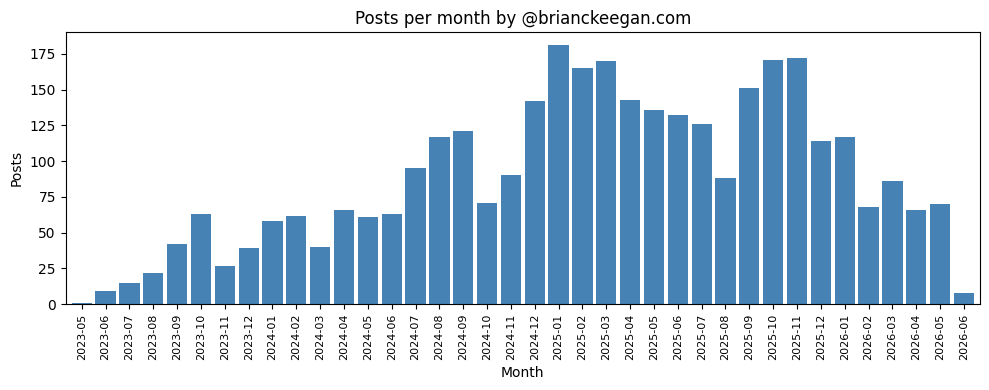

In [28]:
posts_per_month = (
    reloaded_posts
    .set_index('created_at')
    .resample('MS')      # 'MS' = month-start bins (months with no posts count as 0)
    .size()
)

# Label the bars with 'YYYY-MM' strings rather than full timestamps
posts_per_month.index = posts_per_month.index.strftime('%Y-%m')

fig, ax = plt.subplots(figsize=(10, 4))
posts_per_month.plot(kind='bar', ax=ax, color='steelblue', width=0.85)
ax.tick_params(axis='x', labelsize=8)
ax.set_xlabel('Month')
ax.set_ylabel('Posts')
ax.set_title(f'Posts per month by @{HANDLE}')
plt.tight_layout()
plt.savefig(DATA_DIR / 'posts_per_month.png', dpi=150)
plt.show()

Already a research-worthy pattern: posting arrives in bursts — the spike in late 2024 coincides with the great post-US-election Twitter exodus, when millions of new users (and their welcoming committees) flooded onto Bluesky. Part 05 turns exactly this kind of time series into formal event studies.

Some quick structural facts about the posting history, using [`describe()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.describe.html) to summarize the engagement distributions:

In [29]:
print(f"Replies:           {reloaded_posts['is_reply'].mean():.1%} of posts")
print(f"Posts with embeds: {reloaded_posts['has_embed'].mean():.1%} of posts")

reloaded_posts[['like_count', 'repost_count', 'reply_count']].describe().round(1)

Replies:           44.4% of posts
Posts with embeds: 62.3% of posts


,like_count,repost_count,reply_count
count,3368.0,3368.0,3368.0
mean,6.4,0.9,0.4
std,22.6,5.5,0.9
min,0.0,0.0,0.0
25%,1.0,0.0,0.0
50%,2.0,0.0,0.0
75%,5.0,0.0,1.0
max,608.0,154.0,15.0


Note how the mean engagement sits far above the median — a first glimpse of the heavy-tailed distributions that dominate social media, where a handful of viral posts collect most of the attention. Part 04 studies those distributions properly.

Finally, the follow lists let us ask a simple network question as a teaser for Part 03: how reciprocal is this account's neighborhood? Because both DataFrames key on DIDs, the overlap is a set intersection:

In [30]:
follow_dids   = set(follows_df['did'])
follower_dids = set(followers_df['did'])

mutuals = follow_dids & follower_dids

print(f"Follows:   {len(follow_dids):,}")
print(f"Followers: {len(follower_dids):,}")
print(f"Mutuals:   {len(mutuals):,}")
print()
print(f"Share of follows that follow back:    {len(mutuals) / len(follow_dids):.1%}")
print(f"Share of followers that are followed: {len(mutuals) / len(follower_dids):.1%}")

Follows:   2,399
Followers: 4,402
Mutuals:   1,117

Share of follows that follow back:    46.6%
Share of followers that are followed: 25.4%


Kwak et al. (2010) famously asked whether Twitter was "a social network or a news media" based largely on reciprocity rates like these — for one ego so far, but Part 03 scales the question up to whole neighborhoods of the Bluesky graph.

## Ethics and limitations

We deliberately taught the mechanics and the ethics in the same notebook, because they are the same activity: every loop you write collects traces of *people*. Bluesky's openness — no API keys, no paywall, the whole firehose public by protocol design — makes collection astonishingly easy, and that ease is precisely why the judgment has to come from you. Here are the considerations that should shape a collection *before* it runs, drawing on the research-ethics literature this series leans on throughout.

### Public is not the same as consented

Everything we collected today is public — anyone with a browser could read it. It does not follow that the people who posted it agreed to be research subjects. Fiesler & Proferes (2018) surveyed Twitter users about exactly this and found that most had no idea their tweets were used in research, and that many were uncomfortable once they learned — with comfort varying sharply by context: what topic, which study, whether they would be quoted, whether they would be named. Most Bluesky users have never read the AT Protocol documentation and may not realize that their follows, likes, and even their *blocks* are globally readable. "It was public" is where the ethical analysis starts, not where it ends: the [AoIR Internet Research Ethics guidelines](https://aoir.org/reports/ethics3.pdf) (franzke et al. 2020) — the most accessible starting point in this literature, written for researchers without legal training — frame the right question as one of *contextual* expectations — what flows of their information would the people in your dataset reasonably anticipate?

This notebook's own design reflects that: we collected the posting history of the series author, who consented to being the example, rather than pointing our shiny new loop at a stranger. You will not always be able to get consent at scale — almost no observational platform research can — which is exactly why the remaining safeguards matter.

### Minimization, third parties, and what you choose not to collect

The cheapest privacy protection is data you never collect. Our `flatten_post` and `flatten_profile` functions are quietly doing ethics: of the dozens of fields in each response, we kept roughly ten that our research questions actually need, and dropped avatars, descriptions, viewer state, and the rest. **Purpose limitation** is the same principle applied over time — an archive collected to study posting rhythms should not be quietly repurposed into a profiling tool. And notice that minimization has a *who* dimension as well as a *what* dimension: our follower archive contains 5,000 accounts who never interacted with this tutorial — third parties swept in because they once clicked "follow" on the seed account. Network data always implicates people beyond your seed (reply trees and like lists, coming in Part 04, are even more aggressive about this). Prefer aggregates and derived measures when reporting — our reciprocity rate exposes no individual — and think hard before publishing raw lists of identifiable accounts.

### Deletion, withdrawal, and the life of an archive

People delete posts, and deletion is meaningful: it often signals regret, or that content attracted harassment. The live API honors deletions; your Parquet file does not. The archive we saved today will, within months, contain posts their authors have removed from the network. Best practice is layered: record the collection date (our metadata file does), so the archive can be honestly described as "the account as of this date"; re-check against the live API (`get_posts` re-hydrates URIs) before quoting or republishing anything; honor deletions when you share data — one reason Twitter-era data sharing converged on distributing bare IDs for re-hydration rather than full content. Verbatim quotation deserves special caution: a quoted post is trivially re-identifiable by anyone with a search box, even if you "anonymized" the handle (Zimmer 2010) — paraphrase or aggregate, especially on sensitive topics.

### Terms of service, IRBs, and the post-API backdrop

Working through official APIs and [rate limits](https://docs.bsky.app/docs/advanced-guides/rate-limits), as we did today, keeps you inside the platform's [terms of service](https://bsky.social/about/support/tos); Bluesky's openness makes the compliant path unusually generous. That is not a given historically — Freelon (2018) chronicles how Twitter's and Facebook's API closures stranded an entire research field and tempted researchers toward ToS-violating scraping, with all its legal and ethical murk. Open protocols like ATProto are partly a response to that era, but the lesson stands: design your pipeline so its access method is one you could defend in public. And if your work is research involving human subjects, talk to your IRB or ethics board *before* collecting — "public data" does not automatically mean exempt, review standards for trace data vary widely across institutions, and boards increasingly expect a data management plan covering storage, retention, de-identification, and deletion (the metadata habit from Section 6 is the first piece of one).

### Limitations of what we built

Honest reporting also means stating what an archive like today's *cannot* support. Bluesky's users are early adopters and Twitter migrants, not a sample of any general population — prevalence claims do not generalize off-platform, just as Twitter's never did (Ruths & Pfeffer 2014). Engagement counts condition on visible reactions; the protocol exposes no impression or view data, so silent readers are invisible. A single account's history, however complete, supports claims about that account — the census-not-sample logic that made today's frame defensible also bounds it. And the platform itself is in flux: lexicons, limits, and moderation infrastructure are actively evolving, which is why we save snapshots, record parameters, and treat re-collection as a new measurement rather than a refresh.

## Exercises

These extend the notebook in roughly increasing order of ambition. For any exercise that collects new data, follow the discipline from Section 1: write down the sampling frame and estimate the request budget *before* running any loop.

1. **Collect a different account.** Repoint the pipeline at the official [`bsky.app`](https://bsky.app/profile/bsky.app) account (an organizational account, so the ethics are simple). Start from `get_profile` to size the job: its follower count is in the millions, so an exhaustive follower crawl is off the table — cap followers at a small `max_pages` (say 20) and record the truncation honestly in your metadata file.
2. **Change the page size and time it.** Re-collect the posting history with `limit=25` instead of `limit=100`, wrapping each run in [`time.perf_counter()`](https://docs.python.org/3/library/time.html#time.perf_counter). How do the request count and wall-clock time change? This is why you should usually ask for the largest page an endpoint allows.
3. **Explore the `filter` parameter.** [`get_author_feed`](https://docs.bsky.app/docs/api/app-bsky-feed-get-author-feed) accepts `filter` values such as `'posts_no_replies'` and `'posts_with_media'`. Collect the media-only feed and compare its size to the `has_embed` share from Section 7 — they will not match exactly, because embeds include link cards and quoted posts as well as images, and explaining the gap is part of the exercise.
4. **CSV vs. Parquet at different scales.** Slice the post archive to its first 100, 500, 1,000, and all rows; write each slice in both formats; and plot file size (and [`read_csv`](https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html) vs. [`read_parquet`](https://pandas.pydata.org/docs/reference/api/pandas.read_parquet.html) load time) against row count. Does Parquet's advantage grow, shrink, or hold steady as the archive grows?
5. **A polite multi-account crawler.** Sample five accounts from `follows_df` and write a loop that collects each one's most recent ~200 posts with `fetch_all_pages` (`max_pages=2`), pausing between accounts and saving one Parquet file per account plus a single shared metadata JSON. Estimate the total request budget first, then confirm afterward that the actual count matched your estimate.
6. **Watch backoff work — without hammering the server.** Write a fake function that raises an exception shaped like a 429 (see `is_rate_limit_error` in [`collection.py`](collection.py)) on its first two calls and succeeds on the third, then pass it to `call_with_backoff`. You should see two retry messages and then a result — proof that the seatbelt works, achieved with zero real requests.

## Research project ideas

Three research designs that need nothing beyond this notebook's endpoints and methods, each sketched as *question → data → method → expected challenge*. Any of them could anchor a term paper.

**1. The migration cohorts of Bluesky.** Did users who arrived during the post-US-election surge of late 2024 behave differently from earlier adopters — and did they stay? The follower archive we built already contains every account's `created_at` date, so you can define joining cohorts (pre-2024, the November 2024 wave, later arrivals) directly from data you have. Sample a few dozen accounts per cohort, collect their posting histories with `fetch_all_pages`, and compare activity profiles: posts per month since joining, time-to-last-post, share still active today. The expected challenge is the sampling frame (Ruths & Pfeffer 2014): followers of one academic are not Bluesky users in general, so you must either defend that frame explicitly or rebuild it from a more neutral seed — and remember from Section 3 that deleted and suspended accounts have *already* vanished from your follower lists, which biases retention estimates upward.

**2. A social network or a news media?** Kwak et al. (2010) found that only about 22% of Twitter follow relationships were reciprocated and argued that Twitter functioned more like a news medium than a social network. Is Bluesky different? Choose a defensible frame — for instance, all members of a few public starter packs spanning different communities — and for each account collect follows and followers (capping very large accounts with `max_pages` and recording the caps in your metadata), then compute per-account reciprocity exactly as in Section 7. Compare reciprocity across community types and against account size. The expected challenge is scale and politeness: follow lists for even a hundred accounts mean thousands of requests, so this is the project where request budgeting, backoff, and overnight pacing stop being homework and become method.

**3. How fast do archives decay?** Your Parquet file is a snapshot of a moving target: posts get deleted, accounts get suspended, handles change. Take today's archive of post URIs, then once a week re-hydrate a fixed random sample with `get_posts` and record which URIs no longer resolve. After a couple of months you can estimate a deletion rate and ask what kinds of posts disappear — replies? high-engagement posts? posts on particular topics? This design sits directly on the ethics literature: Fiesler & Proferes (2018) show that users expect control over their content, so the deletion-respecting practices from the Ethics and limitations section (distributing IDs rather than content, re-checking before quoting) become your *findings* rather than merely your obligations. The expected challenge is interpretive: you observe that a post vanished but not directly why, so report deletions, suspensions, and other failures as distinct outcomes wherever the API error lets you tell them apart.

## References

The research designs in this series were mostly developed on Twitter, computational social science's longtime model organism. For this part's themes — sampling, platform data access, and research ethics:

### Scholarship

* Fiesler, C., & Proferes, N. (2018). "Participant" perceptions of Twitter research ethics. *Social Media + Society*, 4(1). [https://doi.org/10.1177/2056305118763366](https://doi.org/10.1177/2056305118763366)
* franzke, a. s., Bechmann, A., Zimmer, M., Ess, C., & the Association of Internet Researchers (2020). *Internet Research: Ethical Guidelines 3.0*. [https://aoir.org/reports/ethics3.pdf](https://aoir.org/reports/ethics3.pdf)
* Freelon, D. (2018). Computational research in the post-API age. *Political Communication*, 35(4), 665–668. [https://doi.org/10.1080/10584609.2018.1477506](https://doi.org/10.1080/10584609.2018.1477506)
* Kwak, H., Lee, C., Park, H., & Moon, S. (2010). What is Twitter, a social network or a news media? *Proceedings of WWW '10*, 591–600. [https://doi.org/10.1145/1772690.1772751](https://doi.org/10.1145/1772690.1772751)
* Ruths, D., & Pfeffer, J. (2014). Social media for large studies of behavior. *Science*, 346(6213), 1063–1064. [https://doi.org/10.1126/science.346.6213.1063](https://doi.org/10.1126/science.346.6213.1063)
* Zimmer, M. (2010). "But the data is already public": On the ethics of research in Facebook. *Ethics and Information Technology*, 12(4), 313–325. [https://doi.org/10.1007/s10676-010-9227-5](https://doi.org/10.1007/s10676-010-9227-5)

For tidy data and file formats:

* Wickham, H. (2014). Tidy data. *Journal of Statistical Software*, 59(10). [https://doi.org/10.18637/jss.v059.i10](https://doi.org/10.18637/jss.v059.i10)

### Documentation

* Bluesky rate limits: [https://docs.bsky.app/docs/advanced-guides/rate-limits](https://docs.bsky.app/docs/advanced-guides/rate-limits)
* `app.bsky.feed.getAuthorFeed`: [https://docs.bsky.app/docs/api/app-bsky-feed-get-author-feed](https://docs.bsky.app/docs/api/app-bsky-feed-get-author-feed)
* `app.bsky.graph.getFollows` / `getFollowers`: [https://docs.bsky.app/docs/api/app-bsky-graph-get-follows](https://docs.bsky.app/docs/api/app-bsky-graph-get-follows)
* `app.bsky.actor.getProfiles` (batched lookups): [https://docs.bsky.app/docs/api/app-bsky-actor-get-profiles](https://docs.bsky.app/docs/api/app-bsky-actor-get-profiles)
* ATProto Python SDK: [https://atproto.blue/](https://atproto.blue/)
* AT Protocol specifications: [https://atproto.com/](https://atproto.com/)
* pandas I/O guide (CSV, Parquet, and more): [https://pandas.pydata.org/docs/user_guide/io.html](https://pandas.pydata.org/docs/user_guide/io.html)
* Reading and writing Parquet with pyarrow: [https://arrow.apache.org/docs/python/parquet.html](https://arrow.apache.org/docs/python/parquet.html)

**Next:** [Part 02 — Searching and Snowballing](../Part%2002%20-%20Searching%20and%20Snowballing/) starts from a *topic* instead of an account and builds a deduplicated post archive with search and snowball sampling.